<a href="https://colab.research.google.com/github/AbhinavDharam/Netflix-Content-Strategy-Viewer-Preference-Analysis/blob/main/Netflix_Recommendation_Engine_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd  # For tabular data loading and manipulation
import numpy as np  # For numerical operations and matrix evaluations
import matplotlib.pyplot as plt  # For plotting feature importances and strategy charts
import seaborn as sns  # For visualizing genre correlation heatmaps

from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets
from sklearn.ensemble import RandomForestClassifier  # For supervised modeling of feature combinations
from sklearn.feature_extraction.text import TfidfVectorizer  # For converting plot text descriptions into numerical features
from sklearn.preprocessing import MultiLabelBinarizer  # For encoding multi-label genre lists into binary vectors
from sklearn.metrics import classification_report, accuracy_score  # For reporting evaluation metrics

In [ ]:
# Load cleaned dataset
df = pd.read_csv("cleaned_netflix_data.csv")

# Clean missing values
for col in ['listed_in', 'director', 'cast', 'rating', 'description']:
    df[col] = df[col].fillna('Unknown')

# Feature Engineering: Map raw ratings into 3 Strategic Audience Tiers
rating_map = {
    'TV-MA': 'Adult', 'R': 'Adult', 'NC-17': 'Adult',
    'TV-14': 'Teen/General', 'PG-13': 'Teen/General', 'TV-PG': 'Teen/General',
    'TV-Y': 'Kids/Family', 'TV-Y7': 'Kids/Family', 'TV-G': 'Kids/Family', 'G': 'Kids/Family', 'PG': 'Kids/Family'
}
df['audience_tier'] = df['rating'].map(rating_map).fillna('Other')
df_filtered = df[df['audience_tier'] != 'Other'].copy()

# Parse comma-separated genre lists
df_filtered['genres_list'] = df_filtered['listed_in'].apply(lambda x: [i.strip() for i in x.split(',') if i.strip() != ''])

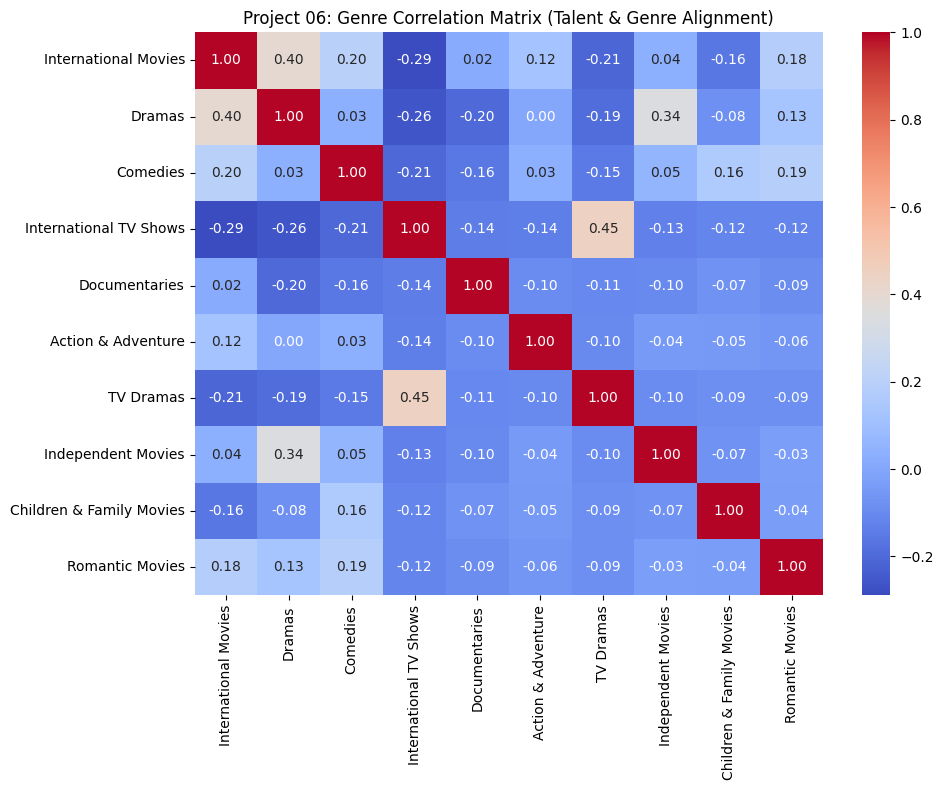

In [ ]:
# 1. CATEGORICAL ENCODING & CORRELATION ANALYSIS (Project 06 Requirement)
mlb_genres = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(
    mlb_genres.fit_transform(df_filtered['genres_list']),
    columns=[f"{c}" for c in mlb_genres.classes_],
    index=df_filtered.index
)

# Plot Genre Correlation Matrix
plt.figure(figsize=(10, 8))
top_genres = genres_encoded.sum().sort_values(ascending=False).head(10).index
sns.heatmap(genres_encoded[top_genres].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Project 06: Genre Correlation Matrix (Talent & Genre Alignment)")
plt.tight_layout()
plt.show()

In [ ]:
# 2. FEATURE MATRIX CONSTRUCTION
tfidf = TfidfVectorizer(max_features=300, stop_words='english')
tfidf_features = pd.DataFrame(
    tfidf.fit_transform(df_filtered['description']).toarray(),
    columns=[f"Text_{w}" for w in tfidf.get_feature_names_out()],
    index=df_filtered.index
)

X = pd.concat([genres_encoded, tfidf_features], axis=1)
y = df_filtered['audience_tier']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model Training
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluation
y_pred = rf_model.predict(X_test)
print("=" * 60)
print(f"Strategic Audience Tier Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("=" * 60)
print("\nDetailed Performance Report:\n")
print(classification_report(y_test, y_pred))


Strategic Audience Tier Accuracy: 65.32%

Detailed Performance Report:

              precision    recall  f1-score   support

       Adult       0.66      0.68      0.67       707
 Kids/Family       0.86      0.81      0.83       206
Teen/General       0.58      0.57      0.58       624

    accuracy                           0.65      1537
   macro avg       0.70      0.69      0.69      1537
weighted avg       0.65      0.65      0.65      1537



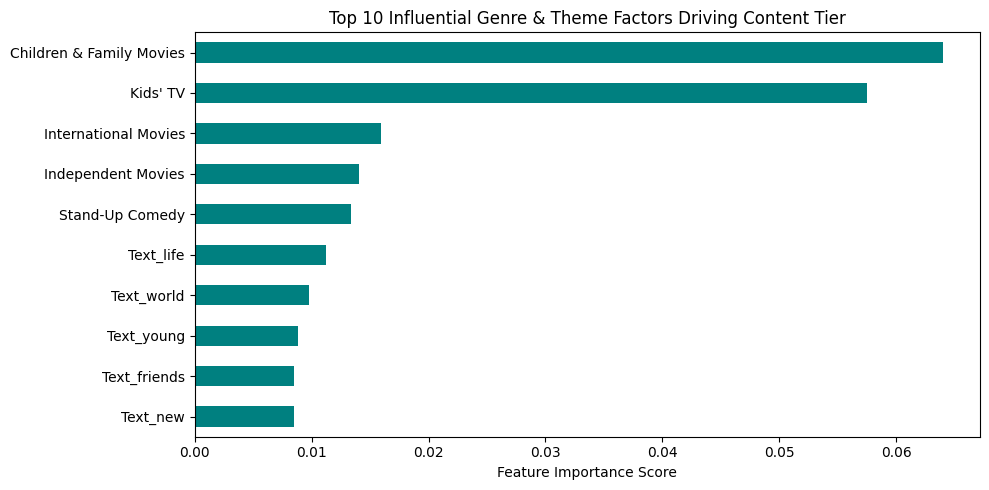


💡 MARKET GAP REPORT FOR GENRE: 'Sci-Fi & Fantasy'
Total Catalogue Count: 292
Audience Tier Breakdown:
  • Teen/General: 52.4%
  • Adult: 37.0%
  • Kids/Family: 10.6%
Strategic Takeaway: Identify tiers with low percentages to spot under-served audiences.


In [ ]:
# 3. FEATURE IMPORTANCE VISUALIZATION
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_drivers = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_drivers.plot(kind='barh', color='teal')
plt.title("Top 10 Influential Genre & Theme Factors Driving Content Tier")
plt.xlabel("Feature Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 4. UNEXPLOITED MARKET GAP IDENTIFIER
def find_market_gaps(genre_name):
    matching_shows = df_filtered[df_filtered['listed_in'].str.contains(genre_name, case=False, na=False)]
    tier_distribution = matching_shows['audience_tier'].value_counts(normalize=True) * 100

    print("\n" + "=" * 60)
    print(f"💡 MARKET GAP REPORT FOR GENRE: '{genre_name}'")
    print("=" * 60)
    print(f"Total Catalogue Count: {len(matching_shows)}")
    print("Audience Tier Breakdown:")
    for tier, pct in tier_distribution.items():
        print(f"  • {tier}: {pct:.1f}%")
    print("Strategic Takeaway: Identify tiers with low percentages to spot under-served audiences.")
    print("=" * 60)

# Run Market Gap Analysis for Sci-Fi
find_market_gaps("Sci-Fi & Fantasy")

In [ ]:
import joblib

In [ ]:
joblib.dump(rf_model, "rf_model.joblib")

['rf_model.joblib']